## AI Energy Analytics Project - Data Preparation & Feature Engineering

## Project Name
**AI Energy Analytics - Smart Meter Energy Consumption Forecasting**

## Objective
To load, clean, integrate, and engineer features from the London Smart Meter datasets
(daily household energy readings, household metadata, daily weather, and UK bank holidays)
in order to build a single, model-ready dataset for **energy consumption forecasting**.


## Workflow
This notebook performs data loading, cleaning, preprocessing, dataset integration,
feature engineering, and prepares the final dataset (`energy_analytics_dataset.csv`)
for downstream energy consumption forecasting models.

**Pipeline:** Load → Inspect → Assess Quality → Clean → Merge → Basic EDA →
Feature Engineering → Validate → Save → Reload & Verify


## Step 1: Import Libraries
Import all required libraries.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 150)

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

print("Libraries imported successfully.")


Libraries imported successfully.


## Step 2: Load Datasets

Load the four datasets.

In [2]:
RAW_DIR = "D:/AI_Energy_Analytics_Project/data/raw"
PROCESSED_DIR = "D:/AI_Energy_Analytics_Project/data/processed"

os.makedirs(PROCESSED_DIR, exist_ok=True)

daily = pd.read_csv(os.path.join(RAW_DIR, "daily_dataset.csv"))
house = pd.read_csv(os.path.join(RAW_DIR, "informations_households.csv"))
weather = pd.read_csv(os.path.join(RAW_DIR, "weather_daily_darksky.csv"))
holiday = pd.read_csv(os.path.join(RAW_DIR, "uk_bank_holidays.csv"), encoding="utf-8")

print("daily   :", daily.shape)
print("house   :", house.shape)
print("weather :", weather.shape)
print("holiday :", holiday.shape)


daily   : (3510433, 9)
house   : (5566, 5)
weather : (882, 32)
holiday : (25, 2)


## 3: Dataset Overview

A reusable helper inspects each dataset for shape, columns, dtypes,
head/tail rows and statistical summaries (numeric + categorical).

In [3]:
def dataset_overview(name, df):
    print("=" * 90)
    print(f"DATASET: {name}")
    print("=" * 90)
    print(f"Shape  : {df.shape}")
    print(f"Columns: {list(df.columns)}\n")

    print("--- Data Types ---")
    print(df.dtypes)

    print("\n--- First 5 Rows ---")
    display(df.head())

    print("\n--- Last 5 Rows ---")
    display(df.tail())

    print("\n--- df.info() ---")
    df.info()

    num_cols = df.select_dtypes(include=np.number).columns
    if len(num_cols) > 0:
        print("\n--- Numerical Summary (describe) ---")
        display(df[num_cols].describe().T)

    cat_cols = df.select_dtypes(include="object").columns
    if len(cat_cols) > 0:
        print("\n--- Categorical Summary (describe include='object') ---")
        display(df[cat_cols].describe())
    print("\n")


In [4]:
dataset_overview("daily_dataset", daily)

DATASET: daily_dataset
Shape  : (3510433, 9)
Columns: ['LCLid', 'day', 'energy_median', 'energy_mean', 'energy_max', 'energy_count', 'energy_std', 'energy_sum', 'energy_min']

--- Data Types ---
LCLid             object
day               object
energy_median    float64
energy_mean      float64
energy_max       float64
energy_count       int64
energy_std       float64
energy_sum       float64
energy_min       float64
dtype: object

--- First 5 Rows ---


,LCLid,day,energy_median,energy_mean,energy_max,energy_count,energy_std,energy_sum,energy_min
0,MAC000131,2011-12-15,0.4850,0.432045,0.868,22,0.239146,9.505,0.072
1,MAC000131,2011-12-16,0.1415,0.296167,1.116,48,0.281471,14.216,0.031
2,MAC000131,2011-12-17,0.1015,0.189812,0.685,48,0.188405,9.111,0.064
3,MAC000131,2011-12-18,0.1140,0.218979,0.676,48,0.202919,10.511,0.065
4,MAC000131,2011-12-19,0.1910,0.325979,0.788,48,0.259205,15.647,0.066



--- Last 5 Rows ---


,LCLid,day,energy_median,energy_mean,energy_max,energy_count,energy_std,energy_sum,energy_min
3510428,MAC004977,2014-02-24,0.0950,0.118458,0.580,48,0.093814,5.686,0.052
3510429,MAC004977,2014-02-25,0.0675,0.084208,0.176,48,0.037107,4.042,0.046
3510430,MAC004977,2014-02-26,0.1080,0.120500,0.282,48,0.069332,5.784,0.046
3510431,MAC004977,2014-02-27,0.0720,0.114062,0.431,48,0.094482,5.475,0.047
3510432,MAC004977,2014-02-28,0.0970,0.097000,0.097,1,NaN,0.097,0.097



--- df.info() ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3510433 entries, 0 to 3510432
Data columns (total 9 columns):
 #   Column         Dtype  
---  ------         -----  
 0   LCLid          object 
 1   day            object 
 2   energy_median  float64
 3   energy_mean    float64
 4   energy_max     float64
 5   energy_count   int64  
 6   energy_std     float64
 7   energy_sum     float64
 8   energy_min     float64
dtypes: float64(6), int64(1), object(2)
memory usage: 241.0+ MB

--- Numerical Summary (describe) ---


,count,mean,std,min,25%,50%,75%,max
energy_median,3510403.0,0.158739,0.170186,0.0,0.067000,0.114500,0.191000,6.970500
energy_mean,3510403.0,0.211730,0.190846,0.0,0.098083,0.163292,0.262458,6.928250
energy_max,3510403.0,0.834521,0.668316,0.0,0.346000,0.688000,1.128000,10.761000
energy_count,3510433.0,47.803636,2.810982,0.0,48.000000,48.000000,48.000000,48.000000
energy_std,3499102.0,0.172667,0.153121,0.0,0.069116,0.132791,0.229312,4.024569
energy_sum,3510403.0,10.124143,9.128793,0.0,4.682000,7.815000,12.569000,332.556001
energy_min,3510403.0,0.059626,0.087013,0.0,0.020000,0.039000,0.071000,6.524000



--- Categorical Summary (describe include='object') ---


,LCLid,day
count,3510433,3510433
unique,5566,829
top,MAC000149,2012-12-18
freq,829,5541


In [5]:
dataset_overview("informations_households", house)

DATASET: informations_households
Shape  : (5566, 5)
Columns: ['LCLid', 'stdorToU', 'Acorn', 'Acorn_grouped', 'file']

--- Data Types ---
LCLid            object
stdorToU         object
Acorn            object
Acorn_grouped    object
file             object
dtype: object

--- First 5 Rows ---


,LCLid,stdorToU,Acorn,Acorn_grouped,file
0,MAC005492,ToU,ACORN-,ACORN-,block_0
1,MAC001074,ToU,ACORN-,ACORN-,block_0
2,MAC000002,Std,ACORN-A,Affluent,block_0
3,MAC003613,Std,ACORN-A,Affluent,block_0
4,MAC003597,Std,ACORN-A,Affluent,block_0



--- Last 5 Rows ---


,LCLid,stdorToU,Acorn,Acorn_grouped,file
5561,MAC002056,Std,ACORN-U,ACORN-U,block_111
5562,MAC004587,Std,ACORN-U,ACORN-U,block_111
5563,MAC004828,Std,ACORN-U,ACORN-U,block_111
5564,MAC001704,ToU,ACORN-U,ACORN-U,block_111
5565,MAC002774,ToU,ACORN-U,ACORN-U,block_111



--- df.info() ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5566 entries, 0 to 5565
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   LCLid          5566 non-null   object
 1   stdorToU       5566 non-null   object
 2   Acorn          5566 non-null   object
 3   Acorn_grouped  5566 non-null   object
 4   file           5566 non-null   object
dtypes: object(5)
memory usage: 217.6+ KB

--- Categorical Summary (describe include='object') ---


,LCLid,stdorToU,Acorn,Acorn_grouped,file
count,5566,5566,5566,5566,5566
unique,5566,2,19,5,112
top,MAC005492,Std,ACORN-E,Affluent,block_0
freq,1,4443,1567,2192,50


In [6]:
dataset_overview("weather_daily_darksky", weather)

DATASET: weather_daily_darksky
Shape  : (882, 32)
Columns: ['temperatureMax', 'temperatureMaxTime', 'windBearing', 'icon', 'dewPoint', 'temperatureMinTime', 'cloudCover', 'windSpeed', 'pressure', 'apparentTemperatureMinTime', 'apparentTemperatureHigh', 'precipType', 'visibility', 'humidity', 'apparentTemperatureHighTime', 'apparentTemperatureLow', 'apparentTemperatureMax', 'uvIndex', 'time', 'sunsetTime', 'temperatureLow', 'temperatureMin', 'temperatureHigh', 'sunriseTime', 'temperatureHighTime', 'uvIndexTime', 'summary', 'temperatureLowTime', 'apparentTemperatureMin', 'apparentTemperatureMaxTime', 'apparentTemperatureLowTime', 'moonPhase']

--- Data Types ---
temperatureMax                 float64
temperatureMaxTime              object
windBearing                      int64
icon                            object
dewPoint                       float64
temperatureMinTime              object
cloudCover                     float64
windSpeed                      float64
pressure           

,temperatureMax,temperatureMaxTime,windBearing,icon,dewPoint,temperatureMinTime,cloudCover,windSpeed,pressure,apparentTemperatureMinTime,apparentTemperatureHigh,precipType,visibility,humidity,apparentTemperatureHighTime,apparentTemperatureLow,apparentTemperatureMax,uvIndex,time,sunsetTime,temperatureLow,temperatureMin,temperatureHigh,sunriseTime,temperatureHighTime,uvIndexTime,summary,temperatureLowTime,apparentTemperatureMin,apparentTemperatureMaxTime,apparentTemperatureLowTime,moonPhase
0,11.96,2011-11-11 23:00:00,123,fog,9.40,2011-11-11 07:00:00,0.79,3.88,1016.08,2011-11-11 07:00:00,10.87,rain,3.30,0.95,2011-11-11 19:00:00,10.87,11.96,1.0,2011-11-11 00:00:00,2011-11-11 16:19:21,10.87,8.85,10.87,2011-11-11 07:12:14,2011-11-11 19:00:00,2011-11-11 11:00:00,Foggy until afternoon.,2011-11-11 19:00:00,6.48,2011-11-11 23:00:00,2011-11-11 19:00:00,0.52
1,8.59,2011-12-11 14:00:00,198,partly-cloudy-day,4.49,2011-12-11 01:00:00,0.56,3.94,1007.71,2011-12-11 02:00:00,5.62,rain,12.09,0.88,2011-12-11 19:00:00,-0.64,5.72,1.0,2011-12-11 00:00:00,2011-12-11 15:52:53,3.09,2.48,8.59,2011-12-11 07:57:02,2011-12-11 14:00:00,2011-12-11 12:00:00,Partly cloudy throughout the day.,2011-12-12 07:00:00,0.11,2011-12-11 20:00:00,2011-12-12 08:00:00,0.53
2,10.33,2011-12-27 02:00:00,225,partly-cloudy-day,5.47,2011-12-27 23:00:00,0.85,3.54,1032.76,2011-12-27 22:00:00,10.33,rain,13.39,0.74,2011-12-27 14:00:00,5.52,10.33,0.0,2011-12-27 00:00:00,2011-12-27 15:57:56,8.03,8.03,10.33,2011-12-27 08:07:06,2011-12-27 14:00:00,2011-12-27 00:00:00,Mostly cloudy throughout the day.,2011-12-27 23:00:00,5.59,2011-12-27 02:00:00,2011-12-28 00:00:00,0.10
3,8.07,2011-12-02 23:00:00,232,wind,3.69,2011-12-02 07:00:00,0.32,3.00,1012.12,2011-12-02 07:00:00,5.33,rain,11.89,0.87,2011-12-02 12:00:00,3.26,5.33,1.0,2011-12-02 00:00:00,2011-12-02 15:56:17,6.33,2.56,7.36,2011-12-02 07:46:09,2011-12-02 12:00:00,2011-12-02 10:00:00,Partly cloudy throughout the day and breezy ov...,2011-12-02 19:00:00,0.46,2011-12-02 12:00:00,2011-12-02 19:00:00,0.25
4,8.22,2011-12-24 23:00:00,252,partly-cloudy-night,2.79,2011-12-24 07:00:00,0.37,4.46,1028.17,2011-12-24 07:00:00,5.02,rain,13.16,0.80,2011-12-24 15:00:00,4.37,5.32,1.0,2011-12-24 00:00:00,2011-12-24 15:55:55,7.45,3.17,7.93,2011-12-24 08:06:15,2011-12-24 15:00:00,2011-12-24 13:00:00,Mostly cloudy throughout the day.,2011-12-24 19:00:00,-0.51,2011-12-24 23:00:00,2011-12-24 20:00:00,0.99



--- Last 5 Rows ---


,temperatureMax,temperatureMaxTime,windBearing,icon,dewPoint,temperatureMinTime,cloudCover,windSpeed,pressure,apparentTemperatureMinTime,apparentTemperatureHigh,precipType,visibility,humidity,apparentTemperatureHighTime,apparentTemperatureLow,apparentTemperatureMax,uvIndex,time,sunsetTime,temperatureLow,temperatureMin,temperatureHigh,sunriseTime,temperatureHighTime,uvIndexTime,summary,temperatureLowTime,apparentTemperatureMin,apparentTemperatureMaxTime,apparentTemperatureLowTime,moonPhase
877,9.03,2014-01-26 16:00:00,233,partly-cloudy-day,2.39,2014-01-26 21:00:00,0.40,4.55,1002.10,2014-01-26 22:00:00,5.99,rain,11.97,0.79,2014-01-26 15:00:00,-2.02,5.99,1.0,2014-01-26 00:00:00,2014-01-26 16:39:26,2.56,3.26,9.03,2014-01-26 07:48:49,2014-01-26 16:00:00,2014-01-26 11:00:00,Mostly cloudy until evening.,2014-01-27 05:00:00,-1.30,2014-01-26 15:00:00,2014-01-27 04:00:00,0.84
878,10.31,2014-02-27 14:00:00,224,partly-cloudy-day,3.08,2014-02-27 23:00:00,0.32,4.14,1007.02,2014-02-27 22:00:00,10.31,rain,12.04,0.74,2014-02-27 14:00:00,0.82,10.31,2.0,2014-02-27 00:00:00,2014-02-27 17:37:35,3.43,3.93,10.31,2014-02-27 06:51:45,2014-02-27 14:00:00,2014-02-27 12:00:00,Partly cloudy until evening.,2014-02-28 02:00:00,1.41,2014-02-27 14:00:00,2014-02-28 02:00:00,0.93
879,18.97,2014-03-09 14:00:00,172,partly-cloudy-night,4.30,2014-03-09 07:00:00,0.04,2.78,1022.44,2014-03-09 07:00:00,18.97,rain,10.62,0.58,2014-03-09 14:00:00,4.12,18.97,3.0,2014-03-09 00:00:00,2014-03-09 17:55:03,5.04,7.65,18.97,2014-03-09 06:29:49,2014-03-09 14:00:00,2014-03-09 12:00:00,Partly cloudy in the evening.,2014-03-10 05:00:00,7.08,2014-03-09 14:00:00,2014-03-10 06:00:00,0.28
880,8.83,2014-02-12 16:00:00,210,wind,1.94,2014-02-12 01:00:00,0.59,7.24,994.27,2014-02-12 01:00:00,4.73,rain,11.80,0.75,2014-02-12 16:00:00,0.05,4.73,1.0,2014-02-12 00:00:00,2014-02-12 17:10:25,4.14,3.03,8.83,2014-02-12 07:21:44,2014-02-12 16:00:00,2014-02-12 10:00:00,Mostly cloudy until evening and breezy through...,2014-02-13 05:00:00,-1.20,2014-02-12 16:00:00,2014-02-13 02:00:00,0.42
881,9.90,2014-02-15 12:00:00,233,wind,2.95,2014-02-15 23:00:00,0.35,9.96,988.63,2014-02-15 23:00:00,5.79,rain,12.38,0.69,2014-02-15 12:00:00,-1.03,5.79,1.0,2014-02-15 00:00:00,2014-02-15 17:15:55,2.34,5.38,9.90,2014-02-15 07:16:06,2014-02-15 12:00:00,2014-02-15 10:00:00,Windy and mostly cloudy until afternoon.,2014-02-16 07:00:00,1.77,2014-02-15 12:00:00,2014-02-16 07:00:00,0.52



--- df.info() ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 882 entries, 0 to 881
Data columns (total 32 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   temperatureMax               882 non-null    float64
 1   temperatureMaxTime           882 non-null    object 
 2   windBearing                  882 non-null    int64  
 3   icon                         882 non-null    object 
 4   dewPoint                     882 non-null    float64
 5   temperatureMinTime           882 non-null    object 
 6   cloudCover                   881 non-null    float64
 7   windSpeed                    882 non-null    float64
 8   pressure                     882 non-null    float64
 9   apparentTemperatureMinTime   882 non-null    object 
 10  apparentTemperatureHigh      882 non-null    float64
 11  precipType                   882 non-null    object 
 12  visibility                   882 non-null    float64
 13  h

,count,mean,std,min,25%,50%,75%,max
temperatureMax,882.0,13.660113,6.182744,-0.06,9.5025,12.625,17.9200,32.40
windBearing,882.0,195.702948,89.340783,0.00,120.5000,219.000,255.0000,359.00
dewPoint,882.0,6.530034,4.830875,-7.84,3.1800,6.380,10.0575,17.77
cloudCover,881.0,0.477605,0.193514,0.00,0.3500,0.470,0.6000,1.00
windSpeed,882.0,3.581803,1.694007,0.20,2.3700,3.440,4.5775,9.96
pressure,882.0,1014.127540,11.073038,979.25,1007.4350,1014.615,1021.7550,1040.92
apparentTemperatureHigh,882.0,12.723866,7.279168,-6.46,7.0325,12.470,17.9100,32.42
visibility,882.0,11.167143,2.466109,1.48,10.3275,11.970,12.8300,15.34
humidity,882.0,0.781871,0.095348,0.43,0.7200,0.790,0.8600,0.98
apparentTemperatureLow,882.0,6.085045,6.031967,-8.88,1.5225,5.315,11.4675,20.54



--- Categorical Summary (describe include='object') ---


,temperatureMaxTime,icon,temperatureMinTime,apparentTemperatureMinTime,precipType,apparentTemperatureHighTime,time,sunsetTime,sunriseTime,temperatureHighTime,uvIndexTime,summary,temperatureLowTime,apparentTemperatureMaxTime,apparentTemperatureLowTime
count,882,882,882,882,882,882,882,882,882,882,881,882,882,882,882
unique,882,6,882,882,2,882,882,882,882,882,881,88,882,882,882
top,2011-11-11 23:00:00,partly-cloudy-day,2011-11-11 07:00:00,2011-11-11 07:00:00,rain,2011-11-11 19:00:00,2011-11-11 00:00:00,2011-11-11 16:19:21,2011-11-11 07:12:14,2011-11-11 19:00:00,2011-11-11 11:00:00,Mostly cloudy throughout the day.,2011-11-11 19:00:00,2011-11-11 23:00:00,2011-11-11 19:00:00
freq,1,619,1,1,862,1,1,1,1,1,1,174,1,1,1


In [7]:
dataset_overview("uk_bank_holidays", holiday)

DATASET: uk_bank_holidays
Shape  : (25, 2)
Columns: ['Bank holidays', 'Type']

--- Data Types ---
Bank holidays    object
Type             object
dtype: object

--- First 5 Rows ---


,Bank holidays,Type
0,2012-12-26,Boxing Day
1,2012-12-25,Christmas Day
2,2012-08-27,Summer bank holiday
3,2012-05-06,Queen?s Diamond Jubilee (extra bank holiday)
4,2012-04-06,Spring bank holiday (substitute day)



--- Last 5 Rows ---


,Bank holidays,Type
20,2014-05-26,Spring bank holiday
21,2014-05-05,Early May bank holiday
22,2014-04-21,Easter Monday
23,2014-04-18,Good Friday
24,2014-01-01,New Year?s Day



--- df.info() ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25 entries, 0 to 24
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Bank holidays  25 non-null     object
 1   Type           25 non-null     object
dtypes: object(2)
memory usage: 532.0+ bytes

--- Categorical Summary (describe include='object') ---


,Bank holidays,Type
count,25,25
unique,25,11
top,2012-12-26,Boxing Day
freq,1,3


## 4: Data Quality Assessment

For each dataset: missing values, duplicate records, unique values
(for categorical columns) and the count of unique values per column.

In [8]:
def quality_report(name, df):
    print("=" * 90)
    print(f"QUALITY REPORT: {name}")
    print("=" * 90)

    print("\n--- Missing Values (count) ---")
    miss = df.isnull().sum()
    miss_pct = (df.isnull().mean() * 100).round(2)
    display(pd.DataFrame({"missing_count": miss, "missing_pct": miss_pct})
            .sort_values("missing_count", ascending=False))

    print(f"\n--- Duplicate Records: {df.duplicated().sum()} ---")

    cat_cols = df.select_dtypes(include="object").columns
    print("\n--- Unique Values (categorical columns) ---")
    for c in cat_cols:
        n_unique = df[c].nunique()
        print(f"{c}: {n_unique} unique values")
        if n_unique <= 20:
            print(f"   values -> {df[c].unique()}")

    print("\n--- nunique() for all columns ---")
    display(df.nunique())
    print("\n")


In [9]:
quality_report("daily_dataset", daily)

QUALITY REPORT: daily_dataset

--- Missing Values (count) ---


,missing_count,missing_pct
energy_std,11331,0.32
energy_median,30,0.00
energy_mean,30,0.00
energy_max,30,0.00
energy_sum,30,0.00
energy_min,30,0.00
LCLid,0,0.00
day,0,0.00
energy_count,0,0.00



--- Duplicate Records: 0 ---

--- Unique Values (categorical columns) ---
LCLid: 5566 unique values
day: 829 unique values

--- nunique() for all columns ---


LCLid               5566
day                  829
energy_median      10015
energy_mean       358607
energy_max          6425
energy_count          44
energy_std       3127706
energy_sum        391015
energy_min          2149
dtype: int64

In [10]:
quality_report("informations_households", house)

QUALITY REPORT: informations_households

--- Missing Values (count) ---


,missing_count,missing_pct
LCLid,0,0.0
stdorToU,0,0.0
Acorn,0,0.0
Acorn_grouped,0,0.0
file,0,0.0



--- Duplicate Records: 0 ---

--- Unique Values (categorical columns) ---
LCLid: 5566 unique values
stdorToU: 2 unique values
   values -> ['ToU' 'Std']
Acorn: 19 unique values
   values -> ['ACORN-' 'ACORN-A' 'ACORN-B' 'ACORN-C' 'ACORN-D' 'ACORN-E' 'ACORN-F'
 'ACORN-G' 'ACORN-H' 'ACORN-I' 'ACORN-J' 'ACORN-K' 'ACORN-L' 'ACORN-M'
 'ACORN-N' 'ACORN-O' 'ACORN-P' 'ACORN-Q' 'ACORN-U']
Acorn_grouped: 5 unique values
   values -> ['ACORN-' 'Affluent' 'Comfortable' 'Adversity' 'ACORN-U']
file: 112 unique values

--- nunique() for all columns ---


LCLid            5566
stdorToU            2
Acorn              19
Acorn_grouped       5
file              112
dtype: int64

In [11]:
quality_report("weather_daily_darksky", weather)

QUALITY REPORT: weather_daily_darksky

--- Missing Values (count) ---


,missing_count,missing_pct
uvIndex,1,0.11
cloudCover,1,0.11
uvIndexTime,1,0.11
temperatureMax,0,0.00
apparentTemperatureLowTime,0,0.00
apparentTemperatureMaxTime,0,0.00
apparentTemperatureMin,0,0.00
temperatureLowTime,0,0.00
summary,0,0.00
temperatureHighTime,0,0.00



--- Duplicate Records: 0 ---

--- Unique Values (categorical columns) ---
temperatureMaxTime: 882 unique values
icon: 6 unique values
   values -> ['fog' 'partly-cloudy-day' 'wind' 'partly-cloudy-night' 'clear-day'
 'cloudy']
temperatureMinTime: 882 unique values
apparentTemperatureMinTime: 882 unique values
precipType: 2 unique values
   values -> ['rain' 'snow']
apparentTemperatureHighTime: 882 unique values
time: 882 unique values
sunsetTime: 882 unique values
sunriseTime: 882 unique values
temperatureHighTime: 882 unique values
uvIndexTime: 881 unique values
summary: 88 unique values
temperatureLowTime: 882 unique values
apparentTemperatureMaxTime: 882 unique values
apparentTemperatureLowTime: 882 unique values

--- nunique() for all columns ---


temperatureMax                 711
temperatureMaxTime             882
windBearing                    304
icon                             6
dewPoint                       687
temperatureMinTime             882
cloudCover                      96
windSpeed                      466
pressure                       802
apparentTemperatureMinTime     882
apparentTemperatureHigh        731
precipType                       2
visibility                     387
humidity                        49
apparentTemperatureHighTime    882
apparentTemperatureLow         718
apparentTemperatureMax         728
uvIndex                          8
time                           882
sunsetTime                     882
temperatureLow                 696
temperatureMin                 694
temperatureHigh                715
sunriseTime                    882
temperatureHighTime            882
uvIndexTime                    881
summary                         88
temperatureLowTime             882
apparentTemperatureM

In [12]:
quality_report("uk_bank_holidays", holiday)

QUALITY REPORT: uk_bank_holidays

--- Missing Values (count) ---


,missing_count,missing_pct
Bank holidays,0,0.0
Type,0,0.0



--- Duplicate Records: 0 ---

--- Unique Values (categorical columns) ---
Bank holidays: 25 unique values
Type: 11 unique values
   values -> ['Boxing Day' 'Christmas Day' 'Summer bank holiday'
 'Queen?s Diamond Jubilee (extra bank holiday)'
 'Spring bank holiday (substitute day)' 'Early May bank holiday'
 'Easter Monday' 'Good Friday' 'New Year?s Day (substitute day)'
 'Spring bank holiday' 'New Year?s Day']

--- nunique() for all columns ---


Bank holidays    25
Type             11
dtype: int64

## 5: Data Cleaning

**Cleaning decisions & rationale**

- **`daily`**
  - Drop exact duplicate rows.
  - `energy_std` is `NaN` only when `energy_count == 1` (a single half-hourly reading gives
    zero variance / undefined std). These are filled with **0** rather than dropped, since
    the record itself is still valid.
  - `day` is converted to `datetime64`.
- **`house`**
  - Drop duplicate rows. No missing values were found, so no imputation is required.
- **`weather`**
  - The date lives in the `time` column → renamed to **`day`** for a consistent merge key
    and parsed as `datetime64` (time component dropped since this is a *daily* dataset).
  - `cloudCover` and `uvIndex` have a handful of missing values → filled with the
    **median** (robust to outliers, appropriate for near-continuous weather metrics).
  - Drop duplicate rows.
- **`holiday`**
  - `Bank holidays` renamed to **`day`** and parsed as `datetime64`.
  - A few `Type` values contain mangled encoding characters (e.g. `Queen?s Diamond Jubilee`) —
    the `?` is replaced with a straight apostrophe for readability.
  - Drop duplicate rows.


In [13]:
# ---- daily ----
daily = daily.drop_duplicates().copy()
daily["day"] = pd.to_datetime(daily["day"], errors="coerce")
daily["energy_std"] = daily["energy_std"].fillna(0)

print("daily cleaned ->", daily.shape)
print("Remaining missing values:\n", daily.isnull().sum())


daily cleaned -> (3510433, 9)
Remaining missing values:
 LCLid             0
day               0
energy_median    30
energy_mean      30
energy_max       30
energy_count      0
energy_std        0
energy_sum       30
energy_min       30
dtype: int64


In [14]:
# ---- house ----
house = house.drop_duplicates().copy()
print("house cleaned ->", house.shape)
print("Remaining missing values:\n", house.isnull().sum())


house cleaned -> (5566, 5)
Remaining missing values:
 LCLid            0
stdorToU         0
Acorn            0
Acorn_grouped    0
file             0
dtype: int64


In [15]:
# ---- weather ----
weather = weather.drop_duplicates().copy()
weather = weather.rename(columns={"time": "day"})
weather["day"] = pd.to_datetime(weather["day"], errors="coerce").dt.normalize()

for col in ["cloudCover", "uvIndex"]:
    if col in weather.columns and weather[col].isnull().sum() > 0:
        weather[col] = weather[col].fillna(weather[col].median())

# keep only the columns useful for merging / modelling to avoid an overly wide table
weather_keep_cols = [
    "day", "temperatureMax", "temperatureMin", "temperatureHigh", "temperatureLow",
    "humidity", "windSpeed", "windBearing", "pressure", "cloudCover",
    "visibility", "uvIndex", "precipType", "icon", "moonPhase", "dewPoint"
]
weather_keep_cols = [c for c in weather_keep_cols if c in weather.columns]
weather = weather[weather_keep_cols].drop_duplicates(subset="day")

print("weather cleaned ->", weather.shape)
print("Remaining missing values:\n", weather.isnull().sum())


weather cleaned -> (879, 16)
Remaining missing values:
 day                0
temperatureMax     0
temperatureMin     0
temperatureHigh    0
temperatureLow     0
humidity           0
windSpeed          0
windBearing        0
pressure           0
cloudCover         0
visibility         0
uvIndex            0
precipType         0
icon               0
moonPhase          0
dewPoint           0
dtype: int64


In [16]:
# ---- holiday ----
holiday = holiday.drop_duplicates().copy()
holiday = holiday.rename(columns={"Bank holidays": "day"})
holiday["Type"] = holiday["Type"].astype(str).str.replace("?", "'", regex=False)
holiday["day"] = pd.to_datetime(holiday["day"], errors="coerce")
holiday["IsHoliday"] = 1

print("holiday cleaned ->", holiday.shape)
display(holiday.head())


holiday cleaned -> (25, 3)


,day,Type,IsHoliday
0,2012-12-26,Boxing Day,1
1,2012-12-25,Christmas Day,1
2,2012-08-27,Summer bank holiday,1
3,2012-05-06,Queen's Diamond Jubilee (extra bank holiday),1
4,2012-04-06,Spring bank holiday (substitute day),1


## 6: Merge Datasets

**Merge order**

1. `daily` **+** `house` on **`LCLid`**
2. Result **+** `weather` on **`day`**
3. Result **+** `holiday` on **`day`**

Each step is verified for shape, missing values and a sample of merged rows.

In [17]:
# Step 1: daily + house  (LCLid)
df = daily.merge(house, on="LCLid", how="left")

print("Step 1 shape:", df.shape)
print("Missing values after Step 1:\n", df.isnull().sum())
display(df.sample(5, random_state=42))


Step 1 shape: (3510433, 13)
Missing values after Step 1:
 LCLid             0
day               0
energy_median    30
energy_mean      30
energy_max       30
energy_count      0
energy_std        0
energy_sum       30
energy_min       30
stdorToU          0
Acorn             0
Acorn_grouped     0
file              0
dtype: int64


,LCLid,day,energy_median,energy_mean,energy_max,energy_count,energy_std,energy_sum,energy_min,stdorToU,Acorn,Acorn_grouped,file
2336348,MAC004411,2013-05-23,0.3815,0.431354,0.761,48,0.160190,20.705,0.131,Std,ACORN-E,Affluent,block_21
1175115,MAC003002,2013-10-07,0.0340,0.034167,0.038,48,0.002244,1.640,0.031,Std,ACORN-H,Comfortable,block_67
3332354,MAC002399,2012-12-01,0.1090,0.168271,0.954,48,0.205144,8.077,0.018,Std,ACORN-E,Affluent,block_18
2067906,MAC001171,2013-10-31,0.1005,0.203396,1.122,48,0.220215,9.763,0.024,Std,ACORN-H,Comfortable,block_66
2946530,MAC000377,2012-05-31,0.1165,0.135271,0.634,48,0.121099,6.493,0.023,Std,ACORN-D,Affluent,block_9


In [18]:
# Step 2: + weather (day)
df = df.merge(weather, on="day", how="left")

print("Step 2 shape:", df.shape)
print("Missing values after Step 2:\n", df.isnull().sum())
display(df.sample(5, random_state=42))


Step 2 shape: (3510433, 28)
Missing values after Step 2:
 LCLid                  0
day                    0
energy_median         30
energy_mean           30
energy_max            30
energy_count           0
energy_std             0
energy_sum            30
energy_min            30
stdorToU               0
Acorn                  0
Acorn_grouped          0
file                   0
temperatureMax     10714
temperatureMin     10714
temperatureHigh    10714
temperatureLow     10714
humidity           10714
windSpeed          10714
windBearing        10714
pressure           10714
cloudCover         10714
visibility         10714
uvIndex            10714
precipType         10714
icon               10714
moonPhase          10714
dewPoint           10714
dtype: int64


,LCLid,day,energy_median,energy_mean,energy_max,energy_count,energy_std,energy_sum,energy_min,stdorToU,Acorn,Acorn_grouped,file,temperatureMax,temperatureMin,temperatureHigh,temperatureLow,humidity,windSpeed,windBearing,pressure,cloudCover,visibility,uvIndex,precipType,icon,moonPhase,dewPoint
2336348,MAC004411,2013-05-23,0.3815,0.431354,0.761,48,0.160190,20.705,0.131,Std,ACORN-E,Affluent,block_21,8.21,5.43,8.21,5.64,0.84,2.24,301.0,1009.40,0.65,11.89,4.0,rain,partly-cloudy-day,0.47,4.40
1175115,MAC003002,2013-10-07,0.0340,0.034167,0.038,48,0.002244,1.640,0.031,Std,ACORN-H,Comfortable,block_67,19.62,13.36,19.62,13.51,0.85,3.13,250.0,1024.75,0.55,10.30,1.0,rain,partly-cloudy-day,0.12,13.79
3332354,MAC002399,2012-12-01,0.1090,0.168271,0.954,48,0.205144,8.077,0.018,Std,ACORN-E,Affluent,block_18,5.73,-1.35,5.73,-1.55,0.88,2.68,274.0,1014.56,0.31,8.92,1.0,rain,fog,0.59,-0.17
2067906,MAC001171,2013-10-31,0.1005,0.203396,1.122,48,0.220215,9.763,0.024,Std,ACORN-H,Comfortable,block_66,13.11,11.61,12.59,11.48,0.89,4.42,217.0,1016.56,0.74,11.36,1.0,rain,partly-cloudy-day,0.89,10.68
2946530,MAC000377,2012-05-31,0.1165,0.135271,0.634,48,0.121099,6.493,0.023,Std,ACORN-D,Affluent,block_9,20.08,13.98,20.08,12.17,0.78,0.84,320.0,1019.08,0.63,11.14,6.0,rain,partly-cloudy-day,0.39,12.69


In [19]:
# Step 3: + holiday (day)
df = df.merge(holiday[["day", "IsHoliday", "Type"]], on="day", how="left")
df["IsHoliday"] = df["IsHoliday"].fillna(0).astype(int)
df = df.rename(columns={"Type": "HolidayName"})

print("Step 3 (final merged) shape:", df.shape)
print("Missing values after Step 3:\n", df.isnull().sum())
display(df.sample(5, random_state=42))


Step 3 (final merged) shape: (3510433, 30)
Missing values after Step 3:
 LCLid                    0
day                      0
energy_median           30
energy_mean             30
energy_max              30
energy_count             0
energy_std               0
energy_sum              30
energy_min              30
stdorToU                 0
Acorn                    0
Acorn_grouped            0
file                     0
temperatureMax       10714
temperatureMin       10714
temperatureHigh      10714
temperatureLow       10714
humidity             10714
windSpeed            10714
windBearing          10714
pressure             10714
cloudCover           10714
visibility           10714
uvIndex              10714
precipType           10714
icon                 10714
moonPhase            10714
dewPoint             10714
IsHoliday                0
HolidayName        3429802
dtype: int64


,LCLid,day,energy_median,energy_mean,energy_max,energy_count,energy_std,energy_sum,energy_min,stdorToU,Acorn,Acorn_grouped,file,temperatureMax,temperatureMin,temperatureHigh,temperatureLow,humidity,windSpeed,windBearing,pressure,cloudCover,visibility,uvIndex,precipType,icon,moonPhase,dewPoint,IsHoliday,HolidayName
2336348,MAC004411,2013-05-23,0.3815,0.431354,0.761,48,0.160190,20.705,0.131,Std,ACORN-E,Affluent,block_21,8.21,5.43,8.21,5.64,0.84,2.24,301.0,1009.40,0.65,11.89,4.0,rain,partly-cloudy-day,0.47,4.40,0,NaN
1175115,MAC003002,2013-10-07,0.0340,0.034167,0.038,48,0.002244,1.640,0.031,Std,ACORN-H,Comfortable,block_67,19.62,13.36,19.62,13.51,0.85,3.13,250.0,1024.75,0.55,10.30,1.0,rain,partly-cloudy-day,0.12,13.79,0,NaN
3332354,MAC002399,2012-12-01,0.1090,0.168271,0.954,48,0.205144,8.077,0.018,Std,ACORN-E,Affluent,block_18,5.73,-1.35,5.73,-1.55,0.88,2.68,274.0,1014.56,0.31,8.92,1.0,rain,fog,0.59,-0.17,0,NaN
2067906,MAC001171,2013-10-31,0.1005,0.203396,1.122,48,0.220215,9.763,0.024,Std,ACORN-H,Comfortable,block_66,13.11,11.61,12.59,11.48,0.89,4.42,217.0,1016.56,0.74,11.36,1.0,rain,partly-cloudy-day,0.89,10.68,0,NaN
2946530,MAC000377,2012-05-31,0.1165,0.135271,0.634,48,0.121099,6.493,0.023,Std,ACORN-D,Affluent,block_9,20.08,13.98,20.08,12.17,0.78,0.84,320.0,1019.08,0.63,11.14,6.0,rain,partly-cloudy-day,0.39,12.69,0,NaN


## 6b: Memory Optimization

**Why this cell was added:** after the three merges, `df` has ~3.5M rows and 30
columns, several of which are stored as generic `object` (Python string) dtype
— `LCLid`, `stdorToU`, `Acorn`, `Acorn_grouped`, `file`, `icon`, `precipType`,
`HolidayName`. At this row count, `object` columns are extremely memory-heavy
because every cell is a separate Python string object.

This caused the two `MemoryError`s later in the notebook:
- **Lag Features cell** — `groupby("LCLid")` on an `object`-typed key with
  3.5M rows needs a large temporary hash table.
- **Final Data Validation cell** — `df.memory_usage(deep=True)` walks every
  string in every `object` column to measure its real size, which is itself
  memory-intensive on a dataframe this size.

**Fix:** convert repeated-value text columns to `category` dtype (stores each
unique value once + a compact integer code) and downcast `float64` → `float32`.
This typically cuts memory by 50–70%. We also delete the now-unused source
dataframes (`daily`, `house`, `weather`, `holiday`) and force garbage
collection to free their memory.

In [20]:
import gc

# Convert low/medium-cardinality text columns to category dtype
cat_cols = ["LCLid", "stdorToU", "Acorn", "Acorn_grouped", "file",
            "icon", "precipType", "HolidayName"]
for c in cat_cols:
    if c in df.columns:
        df[c] = df[c].astype("category")

# Downcast float64 -> float32 (halves memory, precision loss is negligible
# for energy/weather measurements at this scale)
float_cols = df.select_dtypes(include="float64").columns
df[float_cols] = df[float_cols].astype("float32")

# Free memory held by the now-unused source dataframes
del daily, house, weather, holiday
gc.collect()

print(f"Memory usage after optimization: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
df.dtypes

Memory usage after optimization: 351.97 MB


LCLid                    category
day                datetime64[ns]
energy_median             float32
energy_mean               float32
energy_max                float32
energy_count                int64
energy_std                float32
energy_sum                float32
energy_min                float32
stdorToU                 category
Acorn                    category
Acorn_grouped            category
file                     category
temperatureMax            float32
temperatureMin            float32
temperatureHigh           float32
temperatureLow            float32
humidity                  float32
windSpeed                 float32
windBearing               float32
pressure                  float32
cloudCover                float32
visibility                float32
uvIndex                   float32
precipType               category
icon                     category
moonPhase                 float32
dewPoint                  float32
IsHoliday                   int32
HolidayName   

## 7: Exploratory Data Analysis (Basic)

Only high-level checks here — target distribution, outliers, correlations,
missingness pattern, overall consumption trend and temperature distribution.

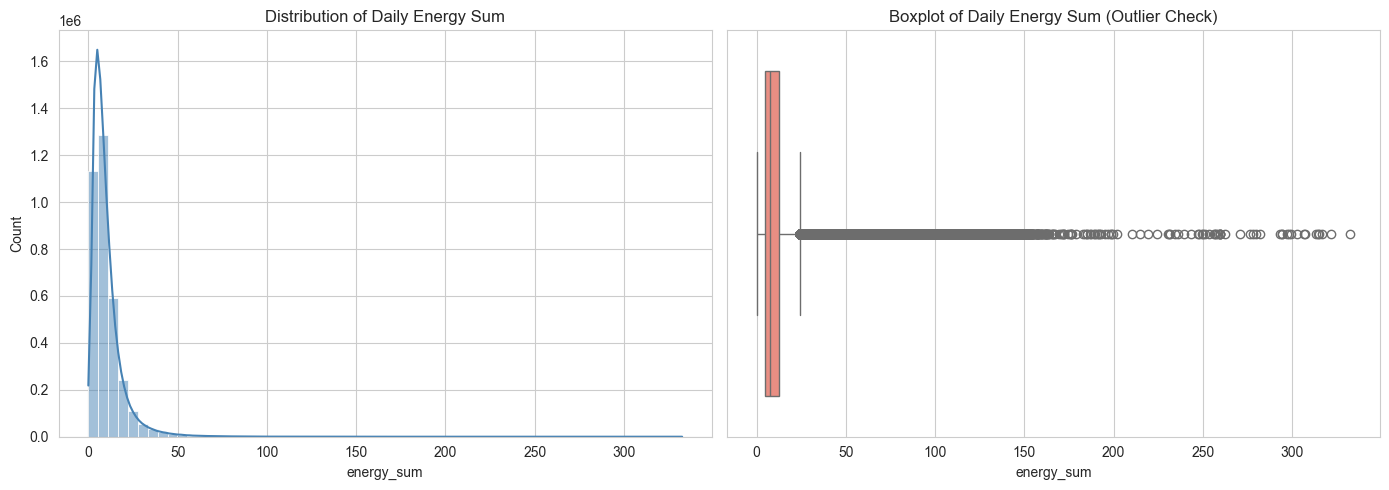

In [21]:
# Target Variable Distribution — energy_sum
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df["energy_sum"], bins=60, kde=True, ax=axes[0], color="steelblue")
axes[0].set_title("Distribution of Daily Energy Sum")
axes[0].set_xlabel("energy_sum")

sns.boxplot(x=df["energy_sum"], ax=axes[1], color="salmon")
axes[1].set_title("Boxplot of Daily Energy Sum (Outlier Check)")

plt.tight_layout()
plt.show()


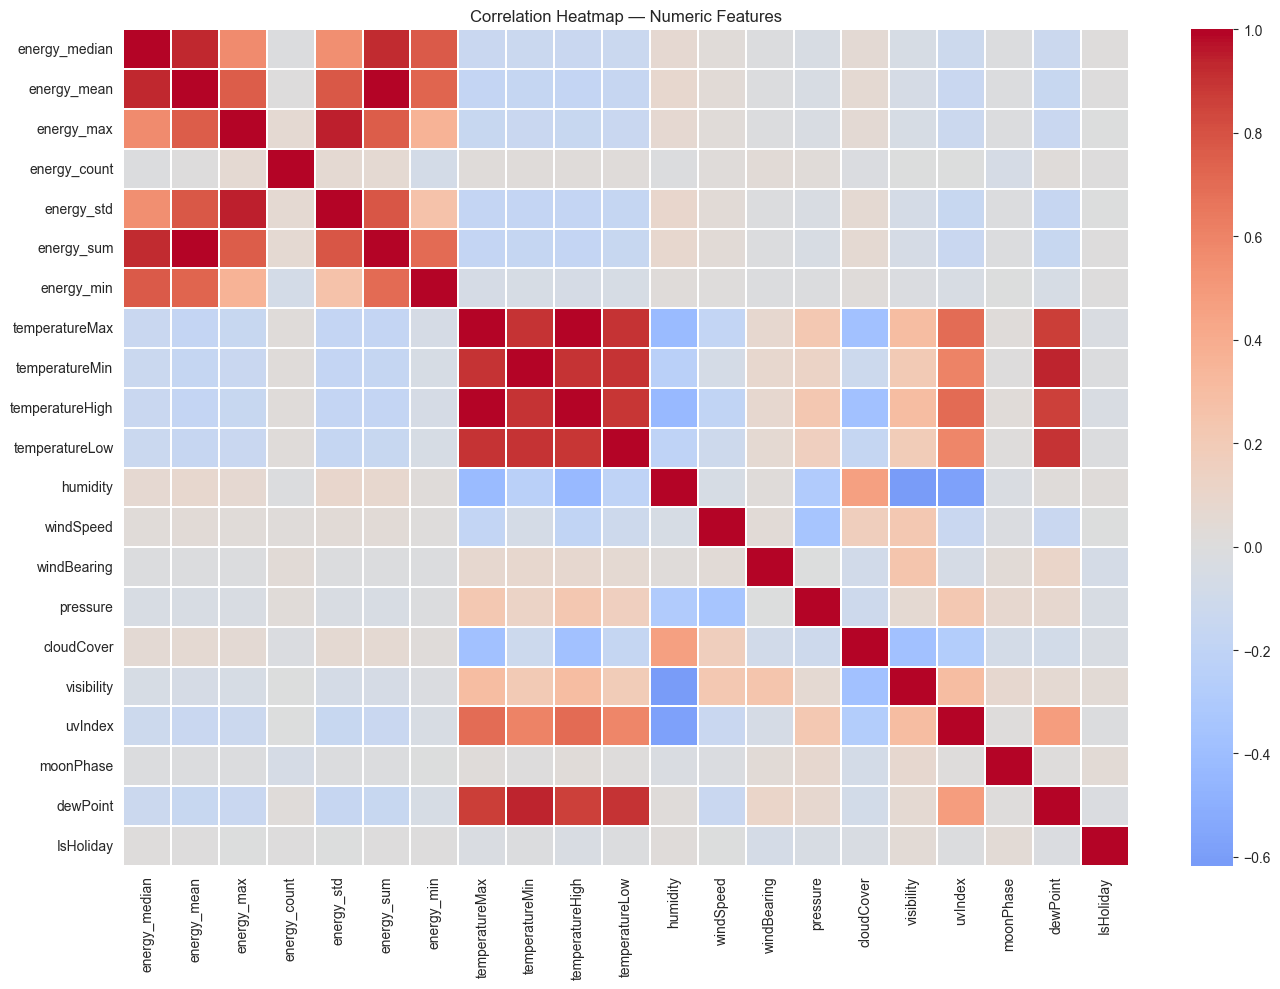

In [22]:
# Correlation Heatmap (numeric columns only)
num_df = df.select_dtypes(include=np.number)
corr = num_df.corr()

plt.figure(figsize=(14, 10))
sns.heatmap(corr, cmap="coolwarm", center=0, annot=False, linewidths=0.3)
plt.title("Correlation Heatmap — Numeric Features")
plt.tight_layout()
plt.show()


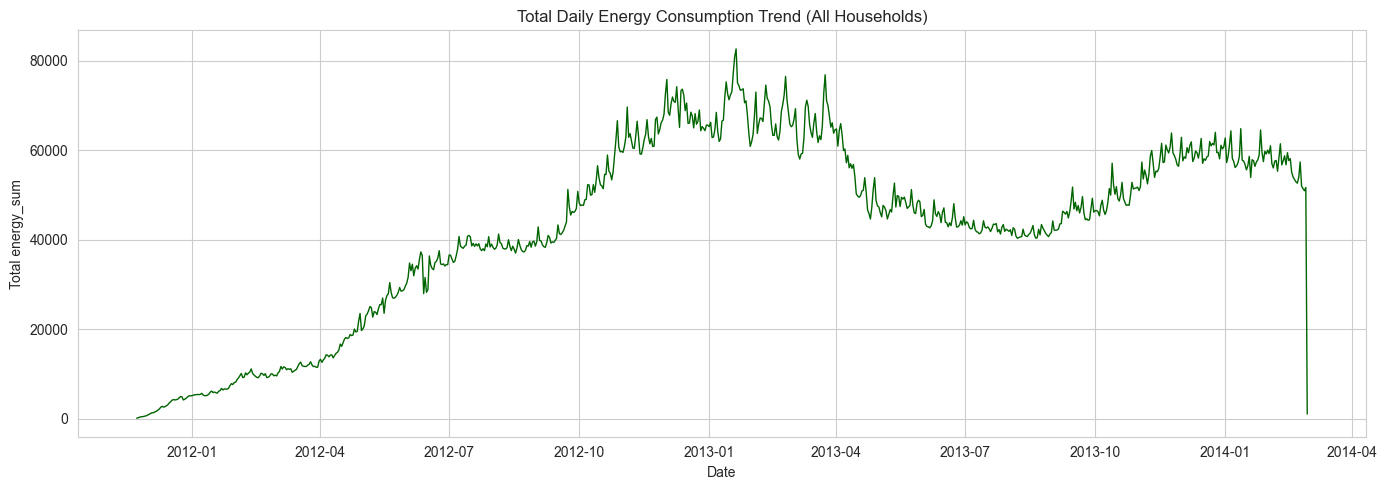

In [23]:
# Energy Consumption Trend (overall, across all households)
trend = df.groupby("day")["energy_sum"].sum().reset_index()

plt.figure(figsize=(14, 5))
plt.plot(trend["day"], trend["energy_sum"], color="darkgreen", linewidth=1)
plt.title("Total Daily Energy Consumption Trend (All Households)")
plt.xlabel("Date")
plt.ylabel("Total energy_sum")
plt.tight_layout()
plt.show()


## 8: Feature Engineering

The most important section — builds the features that power the forecasting model.

In [24]:
# --- Date Features ---
df = df.sort_values(["LCLid", "day"]).reset_index(drop=True)

df["Year"] = df["day"].dt.year
df["Month"] = df["day"].dt.month
df["Day"] = df["day"].dt.day
df["DayOfWeek"] = df["day"].dt.dayofweek          # Monday=0 ... Sunday=6
df["WeekNumber"] = df["day"].dt.isocalendar().week.astype(int)
df["Quarter"] = df["day"].dt.quarter

print(df[["day", "Year", "Month", "Day", "DayOfWeek", "WeekNumber", "Quarter"]].head())


         day  Year  Month  Day  DayOfWeek  WeekNumber  Quarter
0 2012-10-12  2012     10   12          4          41        4
1 2012-10-13  2012     10   13          5          41        4
2 2012-10-14  2012     10   14          6          41        4
3 2012-10-15  2012     10   15          0          42        4
4 2012-10-16  2012     10   16          1          42        4


In [25]:
# --- Weekend Feature ---
# Saturday=5, Sunday=6 in pandas dayofweek
df["IsWeekend"] = df["DayOfWeek"].isin([5, 6]).astype(int)

df[["day", "DayOfWeek", "IsWeekend"]].drop_duplicates().head(10)


,day,DayOfWeek,IsWeekend
0,2012-10-12,4,0
1,2012-10-13,5,1
2,2012-10-14,6,1
3,2012-10-15,0,0
4,2012-10-16,1,0
5,2012-10-17,2,0
6,2012-10-18,3,0
7,2012-10-19,4,0
8,2012-10-20,5,1
9,2012-10-21,6,1


In [26]:
# --- Holiday Feature ---
# IsHoliday was already created during the Section 7 merge (1 = holiday, 0 = normal day)
print(df["IsHoliday"].value_counts())


IsHoliday
0    3429802
1      80631
Name: count, dtype: int64


In [27]:
# --- Season Feature ---
def month_to_season(m):
    if m in [12, 1, 2]:
        return "Winter"
    elif m in [3, 4, 5]:
        return "Spring"
    elif m in [6, 7, 8]:
        return "Summer"
    else:
        return "Autumn"

df["Season"] = df["Month"].apply(month_to_season).astype("category")
df["Season"].value_counts()


Season
Winter    995401
Autumn    949239
Summer    898857
Spring    666936
Name: count, dtype: int64

In [28]:
# --- Lag Features (per household, based on energy_sum) ---
df = df.sort_values(["LCLid", "day"])

df["Lag_1"] = df.groupby("LCLid")["energy_sum"].shift(1)
df["Lag_7"] = df.groupby("LCLid")["energy_sum"].shift(7)
df["Lag_30"] = df.groupby("LCLid")["energy_sum"].shift(30)

df[["LCLid", "day", "energy_sum", "Lag_1", "Lag_7", "Lag_30"]].head(10)


,LCLid,day,energy_sum,Lag_1,Lag_7,Lag_30
0,MAC000002,2012-10-12,7.098,NaN,NaN,NaN
1,MAC000002,2012-10-13,11.087,7.098,NaN,NaN
2,MAC000002,2012-10-14,13.223,11.087,NaN,NaN
3,MAC000002,2012-10-15,10.257,13.223,NaN,NaN
4,MAC000002,2012-10-16,9.769,10.257,NaN,NaN
5,MAC000002,2012-10-17,10.885,9.769,NaN,NaN
6,MAC000002,2012-10-18,10.751,10.885,NaN,NaN
7,MAC000002,2012-10-19,8.431,10.751,7.098,NaN
8,MAC000002,2012-10-20,17.378,8.431,11.087,NaN
9,MAC000002,2012-10-21,24.490,17.378,13.223,NaN


In [29]:
# --- Rolling Features (per household) ---
grp = df.groupby("LCLid")["energy_sum"]

df["Rolling_Mean_3"] = grp.transform(lambda s: s.shift(1).rolling(window=3).mean())
df["Rolling_Mean_7"] = grp.transform(lambda s: s.shift(1).rolling(window=7).mean())
df["Rolling_Std_7"] = grp.transform(lambda s: s.shift(1).rolling(window=7).std())

df[["LCLid", "day", "energy_sum", "Rolling_Mean_3", "Rolling_Mean_7", "Rolling_Std_7"]].head(10)


,LCLid,day,energy_sum,Rolling_Mean_3,Rolling_Mean_7,Rolling_Std_7
0,MAC000002,2012-10-12,7.098,NaN,NaN,NaN
1,MAC000002,2012-10-13,11.087,NaN,NaN,NaN
2,MAC000002,2012-10-14,13.223,NaN,NaN,NaN
3,MAC000002,2012-10-15,10.257,10.469333,NaN,NaN
4,MAC000002,2012-10-16,9.769,11.522333,NaN,NaN
5,MAC000002,2012-10-17,10.885,11.083000,NaN,NaN
6,MAC000002,2012-10-18,10.751,10.303667,NaN,NaN
7,MAC000002,2012-10-19,8.431,10.468334,10.438571,1.830807
8,MAC000002,2012-10-20,17.378,10.022333,10.629000,1.456492
9,MAC000002,2012-10-21,24.490,12.186667,11.527714,2.955606


In [30]:
# --- Temperature Categories ---
if "temperatureMax" in df.columns:
    def temp_category(t):
        if pd.isna(t):
            return np.nan
        elif t < 10:
            return "Cold"
        elif t <= 20:
            return "Normal"
        else:
            return "Hot"

    df["TemperatureCategory"] = df["temperatureMax"].apply(temp_category).astype("category")
    print(df["TemperatureCategory"].value_counts())


TemperatureCategory
Normal    1725735
Cold      1054376
Hot        719608
Name: count, dtype: int64


In [31]:
# --- Tariff Encoding ---
df["TariffEncoded"] = df["stdorToU"].map({"Std": 0, "ToU": 1})
print(df["TariffEncoded"].value_counts())


TariffEncoded
0    2804402
1     706031
Name: count, dtype: int64


In [32]:
# --- ACORN Encoding ---
# Label Encoding for the detailed Acorn code
df["Acorn_LabelEncoded"] = df["Acorn"].astype("category").cat.codes

# One-Hot Encoding for the grouped, lower-cardinality Acorn_grouped column
acorn_dummies = pd.get_dummies(df["Acorn_grouped"], prefix="AcornGroup")
df = pd.concat([df, acorn_dummies], axis=1)

print("Acorn unique codes:", df["Acorn"].nunique())
print("Acorn_grouped one-hot columns:", list(acorn_dummies.columns))


Acorn unique codes: 19
Acorn_grouped one-hot columns: ['AcornGroup_ACORN-', 'AcornGroup_ACORN-U', 'AcornGroup_Adversity', 'AcornGroup_Affluent', 'AcornGroup_Comfortable']


## 9: Final Data Validation

In [33]:
print("Final shape:", df.shape)

print("\nMissing values:\n", df.isnull().sum()[df.isnull().sum() > 0])

print("\nDuplicate rows:", df.duplicated().sum())

print("\nData types:\n", df.dtypes)

try:
    mem_mb = df.memory_usage(deep=True).sum() / 1024**2
except MemoryError:
    mem_mb = df.memory_usage(deep=False).sum() / 1024**2
    print("Note: deep memory scan failed (low RAM) - showing a shallow estimate instead.")
print(f"\nMemory usage: {mem_mb:.2f} MB")


Final shape: (3510433, 52)

Missing values:
 energy_median               30
energy_mean                 30
energy_max                  30
energy_sum                  30
energy_min                  30
temperatureMax           10714
temperatureMin           10714
temperatureHigh          10714
temperatureLow           10714
humidity                 10714
windSpeed                10714
windBearing              10714
pressure                 10714
cloudCover               10714
visibility               10714
uvIndex                  10714
precipType               10714
icon                     10714
moonPhase                10714
dewPoint                 10714
HolidayName            3429802
Lag_1                     5574
Lag_7                    38936
Lag_30                  166747
Rolling_Mean_3           16698
Rolling_Mean_7           38938
Rolling_Std_7            38938
TemperatureCategory      10714
dtype: int64

Duplicate rows: 0

Data types:
 LCLid                           category


## Section 11: Save Processed Dataset

In [34]:
output_path = os.path.join(PROCESSED_DIR, "energy_analytics_dataset.csv")
df.to_csv(output_path, index=False)
print(f"Saved cleaned & feature-engineered dataset -> {output_path}")
print("Final shape:", df.shape)


Saved cleaned & feature-engineered dataset -> D:/AI_Energy_Analytics_Project/data/processed\energy_analytics_dataset.csv
Final shape: (3510433, 52)


## 11: Reload Dataset (Verification)

In [35]:
df_check = pd.read_csv(output_path)

print("Reloaded shape:", df_check.shape)
print("\nColumns:\n", list(df_check.columns))
print("\nMissing values:\n", df_check.isnull().sum()[df_check.isnull().sum() > 0])
display(df_check.sample(5, random_state=1))


Reloaded shape: (3510433, 52)

Columns:
 ['LCLid', 'day', 'energy_median', 'energy_mean', 'energy_max', 'energy_count', 'energy_std', 'energy_sum', 'energy_min', 'stdorToU', 'Acorn', 'Acorn_grouped', 'file', 'temperatureMax', 'temperatureMin', 'temperatureHigh', 'temperatureLow', 'humidity', 'windSpeed', 'windBearing', 'pressure', 'cloudCover', 'visibility', 'uvIndex', 'precipType', 'icon', 'moonPhase', 'dewPoint', 'IsHoliday', 'HolidayName', 'Year', 'Month', 'Day', 'DayOfWeek', 'WeekNumber', 'Quarter', 'IsWeekend', 'Season', 'Lag_1', 'Lag_7', 'Lag_30', 'Rolling_Mean_3', 'Rolling_Mean_7', 'Rolling_Std_7', 'TemperatureCategory', 'TariffEncoded', 'Acorn_LabelEncoded', 'AcornGroup_ACORN-', 'AcornGroup_ACORN-U', 'AcornGroup_Adversity', 'AcornGroup_Affluent', 'AcornGroup_Comfortable']

Missing values:
 energy_median               30
energy_mean                 30
energy_max                  30
energy_sum                  30
energy_min                  30
temperatureMax           10714
tempe

,LCLid,day,energy_median,energy_mean,energy_max,energy_count,energy_std,energy_sum,energy_min,stdorToU,Acorn,Acorn_grouped,file,temperatureMax,temperatureMin,temperatureHigh,temperatureLow,humidity,windSpeed,windBearing,pressure,cloudCover,visibility,uvIndex,precipType,icon,moonPhase,dewPoint,IsHoliday,HolidayName,Year,Month,Day,DayOfWeek,WeekNumber,Quarter,IsWeekend,Season,Lag_1,Lag_7,Lag_30,Rolling_Mean_3,Rolling_Mean_7,Rolling_Std_7,TemperatureCategory,TariffEncoded,Acorn_LabelEncoded,AcornGroup_ACORN-,AcornGroup_ACORN-U,AcornGroup_Adversity,AcornGroup_Affluent,AcornGroup_Comfortable
1919920,MAC002976,2012-12-24,0.0000,0.000000,0.000,48,0.000000,0.000,0.000,Std,ACORN-Q,Adversity,block_101,12.30,7.57,12.30,7.25,0.91,4.28,201.0,999.12,0.61,10.85,1.0,rain,wind,0.38,8.28,0,NaN,2012,12,24,0,52,4,0,Winter,0.000,0.000,0.000,0.000000,0.000000,0.000000,Normal,0,17,False,False,True,False,False
652,MAC000003,2012-07-16,0.1965,0.292063,1.511,48,0.299584,14.019,0.066,Std,ACORN-P,Adversity,block_91,22.44,13.92,22.44,14.91,0.77,4.90,254.0,1022.06,0.55,12.81,5.0,rain,partly-cloudy-day,0.94,14.26,0,NaN,2012,7,16,0,29,3,0,Summer,11.965,11.406,13.931,12.722666,12.171143,1.203238,Hot,0,16,False,False,True,False,False
3148121,MAC005030,2012-07-16,0.1655,0.177729,0.578,48,0.085842,8.531,0.031,Std,ACORN-E,Affluent,block_28,22.44,13.92,22.44,14.91,0.77,4.90,254.0,1022.06,0.55,12.81,5.0,rain,partly-cloudy-day,0.94,14.26,0,NaN,2012,7,16,0,29,3,0,Summer,8.491,8.106,8.482,8.206333,8.664000,1.009179,Hot,0,5,False,False,False,True,False
497123,MAC000694,2013-12-22,0.1450,0.186688,0.792,48,0.124451,8.961,0.069,Std,ACORN-L,Adversity,block_82,10.07,4.81,10.07,4.81,0.73,5.66,234.0,1009.77,0.25,12.68,1.0,rain,partly-cloudy-day,0.66,3.57,0,NaN,2013,12,22,6,51,4,1,Winter,8.658,8.630,8.633,9.026333,9.639571,0.933104,Normal,0,12,False,False,True,False,False
166861,MAC000218,2012-12-23,0.2980,0.346271,0.908,48,0.203861,16.621,0.076,Std,ACORN-E,Affluent,block_21,13.08,9.34,12.56,7.57,0.86,5.51,231.0,1003.59,0.53,12.73,1.0,rain,partly-cloudy-day,0.35,9.30,0,NaN,2012,12,23,6,51,4,1,Winter,17.334,22.736,14.394,15.310666,15.470428,3.701455,Normal,0,5,False,False,False,True,False
